# Particle Swarm Optimisation with Dynamic Strategy

**Notation:** in this notebook we will refer to the following variables meaning
- $D$ = search space dimension ($D=2$ in the location problem)
- $N$ = population size
- $M$ = number of objective functions (same as the number of facility types)
- $K_i$ = number of facilities of type $i$, for $i \in \{1, \dots, M\}$


In [241]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from pymoo.operators.survival.rank_and_crowding.metrics import calc_crowding_distance
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from scipy.sparse.csgraph import connected_components
from dataclasses import dataclass, field
from tqdm import tqdm
import copy


## Sperimental setup

In [242]:

facilities = {
    'ES': np.array([[3, 37], [42, 96], [45, 60], [50, 25], [83, 72],[98, 38]]),
    'HS': np.array([[40, 20], [51, 60], [95, 51]]),
    'CS': np.array([[10, 55], [15, 15], [15, 78], [15, 88], [20, 23],[20, 70], [32, 42], [35, 60], [40, 76], [52, 78],[52, 96], [55, 33], [75, 27]]),
    'RS': np.array([[17.5, 82.5], [55.5, 82.5], [94.5, 6.5]])
}

infrastructure = {
    'Roads': [
    # Major Horizontals
    [(0, 7), (100, 7)],
    [(0, 5.5), (100, 5.5)],
    [(0, 58), (100, 58)],
    [(0, 56.5), (100, 56.5)],
    [(0, 94), (100, 94)],
    [(0, 92.5), (100, 92.5)],
    
    [(19.6, 74), (100, 74)],

    # Minor Horizontals (interrupted by the center block)
    [(0, 40), (34, 40)],
    [(42, 31), (76, 31)],
    
    # Major Verticals
    [(17, 0), (17, 100)],
    [(18.5, 0), (18.5, 100)],
    [(77, 7), (77, 58)],
    
    # Minor Verticals (interrupted by the center block)
    [(42, 7), (42, 31)],
    [(34, 40), (34, 58)],
    [(55.5, 58), (55.5, 82.5)],
    
    # Diagonals branching off the center block
    [(40, 58), (30, 74)],
    [(34, 40), (42, 31)], # Up-right diagonal
    ],
    
    'Railways': [
        [(0, 82.5), (100,82.5)],
        [(0, 82.5), (17.5, 82.5), (55.5, 82), (83, 68), (94.5, 35), (94.35,6.5), (94.5, 0)] 
    ]
}

map_styles = {
    'ES': {'color': '#ff4c4c', 'marker': 'o', 'size': 80},
    'HS':       {'color': '#4c72ff', 'marker': 'o', 'size': 80},
    'CS':           {'color': "#00ff00", 'marker': 'o', 'size': 80},
    'RS':           {'color': '#ffcc00', 'marker': 'o', 'size': 80},
    'Roads':                   {'color': "#B6B5B5", 'linestyle': '-', 'linewidth': 7, 'alpha': 1},
    'Railways':                {'color': '#000000', 'linestyle': '--', 'linewidth': 2, 'alpha': 0.8, 'smooth': True}
}

In [243]:
def smooth_path(path, iterations=4):
    """
    Smooths a path using Chaikin's corner-cutting algorithm.
    This strictly prevents 'wobbling' or overshooting.
    """
    if len(path) < 3:
        return path

    current_path = path
    # The more iterations, the smoother the curve. 4 or 5 is usually perfect.
    for _ in range(iterations):
        new_path = [current_path[0]] # Anchor the very first starting point
        
        for i in range(len(current_path) - 1):
            p0 = current_path[i]
            p1 = current_path[i+1]
            
            # Find the points 25% and 75% of the way along the line segment
            q = (0.75 * p0[0] + 0.25 * p1[0], 0.75 * p0[1] + 0.25 * p1[1])
            r = (0.25 * p0[0] + 0.75 * p1[0], 0.25 * p0[1] + 0.75 * p1[1])
            
            # Add those new points to shave off the corner
            new_path.extend([q, r])
            
        new_path.append(current_path[-1]) # Anchor the very last ending point
        current_path = new_path
        
    return current_path

def plot_city_map(point_data, line_data, styles):
    """
    Plots a generic 2D map. Now supports automatic smoothing for lines.
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    # 1. Plot Lines (Roads, Railways)
    for category, paths in line_data.items():
        style = styles.get(category, {})
        color = style.get('color', 'black')
        linestyle = style.get('linestyle', '-')
        linewidth = style.get('linewidth', 2)
        alpha = style.get('alpha', 1.0)
        
        # Check if the style dictionary requests smoothing for this category
        smooth = style.get('smooth', False) 
        
        for i, path in enumerate(paths):
            if len(path) == 0:
                continue
            
            # Apply smoothing if requested
            plot_path = smooth_path(path) if smooth else path
            
            x_coords, y_coords = zip(*plot_path)
            label = category if i == 0 else ""
            
            ax.plot(x_coords, y_coords, color=color, linestyle=linestyle, 
                    linewidth=linewidth, alpha=alpha, label=label, zorder=1)

    # 2. Plot Points (Facilities)
    for category, points in point_data.items():
        if len(points) == 0:
            continue
            
        style = styles.get(category, {})
        color = style.get('color', 'black')
        marker = style.get('marker', 'o')
        size = style.get('size', 70)
        
        x_coords, y_coords = zip(*points)
        ax.scatter(x_coords, y_coords, color=color, marker=marker, s=size, 
                   edgecolors='black', linewidths=1.5, label=category, zorder=3)

    # 3. Environment & Styling
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    if line_data:
        ax.grid(False)
    else:
        ax.grid(True, linestyle=':', alpha=0.8, zorder=0)

    ax.set_aspect('equal')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Procedural City Infrastructure Map')
    
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

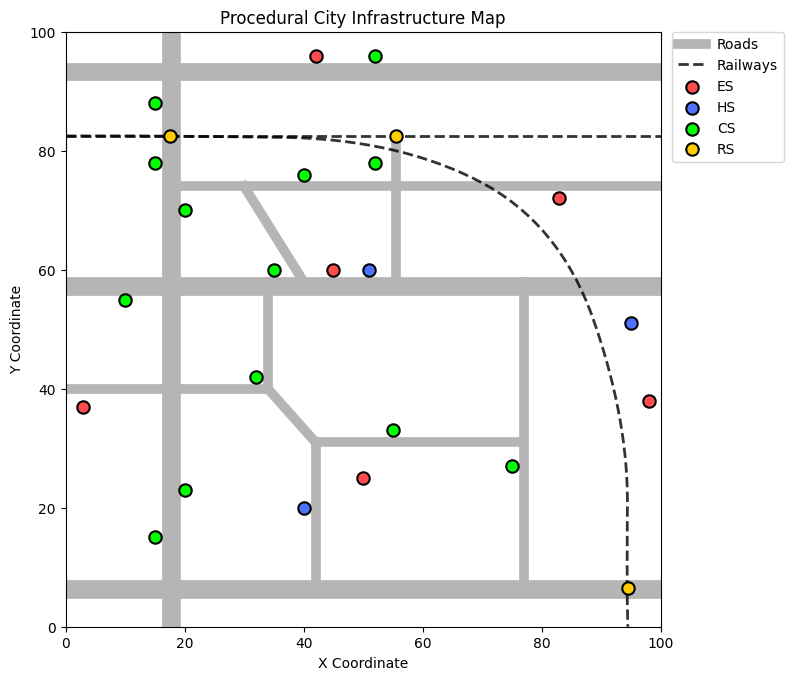

In [244]:
plot_city_map(facilities,infrastructure, map_styles)
# plot_city_map_smooth(facilities,{}, map_styles)

In [245]:
def plot_city_map_with_solutions(point_data, line_data, styles, solutions, label="Solutions", color="#ff00ff", marker="*", size=150):
    """
    Wrapper around plot_city_map that temporarily injects algorithm solutions 
    (or population history) into the plotting dictionaries without mutating the originals.
    
    Inputs:
        point_data: the facilities dictionary.
        line_data: the infrastructure dictionary.
        styles: The map_styles dictionary.
        solutions: np.array of shape (N, D) representing the points to plot.
        label: The legend label for the new points.
        color, marker, size: Plotting style properties for the solutions.
    """
    # Create copies to prevent mutating the global dictionaries
    points_copy = copy.deepcopy(point_data)
    styles_copy = copy.deepcopy(styles)
    
    # Inject the new points and their styling
    points_copy[label] = solutions
    styles_copy[label] = {
        'color': color, 
        'marker': marker, 
        'size': size
    }
    
    # Call the existing plotting function
    plot_city_map(points_copy, line_data, styles_copy)

## PSO-DN algorithm

### Problem parameters

In [ ]:
D = 2
M = 4
K = [6,3,13,3]

x_bounds = [[0, 100], [0, 100]]
v_bounds = [[0.001, 1], [0.001, 1]]

### PSO-DN parameters

In [ ]:
N = 100
c1 = 1.49445
c2 = 1.49445
w = 0.8 * np.ones(D)
R_l = 1    #try printing the number of neighbors and check
n_iter = 500

### Fitness evaluation

In [272]:
def evaluate_population(pop, facilities):
    """
    Computes the objective values for the entire population.
    Input:
        pop: np.array of size (N,D)
        facilities: dictionary of M numpy arrays of shape [K_i, D].
    Output:
        np array of size (N,M), each row contains the fitness values of one individual
    """
    fitness_scores = []
    
    # ensure the objectives order is always consistent
    facility_keys = sorted(facilities.keys())

    for key in facility_keys:
        # euclidean distance from every individual to every facility of this type
        dist_matrix = distance.cdist(pop, facilities[key], metric='euclidean')
        
        # the objective is the distance to the closest one
        nearest_distances = dist_matrix.min(axis=1)     # array of size N
        fitness_scores.append(nearest_distances)
        
    # fitness_score is a list of M arrays of size N
    # stack the list into an (N, M) matrix
    return np.column_stack(fitness_scores)

In [273]:
def multi_objective_fitness(position, facilities):
    """
    Computes the M objective values for a given position.
    Input:
        position: np.array of size D
        facilities: dictionary of M numpy arrays of shape [K_i, D].
    Output:
        np array of M fitness values
    """
    objectives = []
    
    # ensure the objectives order is always consistent
    facility_keys = sorted(facilities.keys())

    for key in facility_keys:
        
        # Euclidean distances from the current position to ALL stations of this type
        distances = np.linalg.norm(facilities[key] - position, axis=1)
        
        # the objective is the distance to the closest one
        min_distance = np.min(distances)
        objectives.append(min_distance)
        
    return np.array(objectives)

In [274]:
def set_distance(x, S):
    """
    Single objective evaluation: returns f_i(x) 
    where   x: an individual
            S: set of facilities of type i
    """
    return min([np.linalg.norm(x-s)] for s in S)

### Special Crowding Distance

In [275]:
def standard_cd(front):
    """
    Vectorized computation of crowding distance for a specific front.
    Input:
        front: np.array of shape (F, D) where F is the number of particles in the front.
    Output:
        cd: np.array of shape (F,)
    """
    F, D = front.shape
    cd = np.zeros(F)
    
    # if front has 2 or fewer items, they are boundaries, assign infinity
    if F <= 2:
        return np.full(F, np.inf)
        
    for i in range(D):
        # indices that would sort this dimension
        sorted_indices = np.argsort(front[:, i])
        sorted_vals = front[sorted_indices, i]
        
        # set boundaries to infinity
        cd[sorted_indices[0]] = np.inf
        cd[sorted_indices[-1]] = np.inf
        
        # compute the range (max - min) for normalization
        val_range = sorted_vals[-1] - sorted_vals[0]
        if val_range == 0:
            continue
            
        # update all intermediate points
        cd_updates = (sorted_vals[2:] - sorted_vals[:-2]) / val_range
        cd[sorted_indices[1:-1]] += cd_updates
        
    return cd

In [276]:
def scd_for_front(front_positions, front_fitnesses):
    """
    Computes SCD for a single front.
    Inputs: 
        front_positions: np.array of shape (F,D)
        front_positions: np.array of shape (F,M)
    Output:
        scd: np.array of shape (F,) of scd values
    """
    # print("front position shape:", front_positions.shape)
    # print("front fitnesses shape:", front_fitnesses.shape)

    # compute standard CD in both spaces (pymoo)
    CD_x = calc_crowding_distance(front_positions)
    CD_F = calc_crowding_distance(front_fitnesses)
    
    # CD_x = standard_cd(front_positions)
    # CD_F = standard_cd(front_fitnesses)
    
    # compute average CD (ignoring infinity boundaries and the case front size <= 2)
    finite_CD_x = CD_x[np.isfinite(CD_x)]
    finite_CD_F = CD_F[np.isfinite(CD_F)]
    
    CD_avg_x = np.mean(finite_CD_x) if len(finite_CD_x) > 0 else 0
    CD_avg_F = np.mean(finite_CD_F) if len(finite_CD_F) > 0 else 0
    
    # distinguish the case where one of the two CDs is above the average
    condition = (CD_x > CD_avg_x) | (CD_F > CD_avg_F)
    
    scd = np.where(condition, 
                   np.maximum(CD_x, CD_F), 
                   np.minimum(CD_x, CD_F))
                   
    # print("scd single front shape:", scd.shape)
    
    return scd

In [277]:
def get_sorted_fronts_and_scd(positions, fitnesses, nds):
    """
    Sorts the population into non-dominated fronts using pymoo, computes 
    the SCD for each front, and returns the sorted fronts and the SCD values.
    Inputs:
        positions: np.array with shape (N, D) of particle positions
        fitnesses: np.array with shape (N, M) of the fitness values
        nds: an instantiated pymoo NonDominatedSorting object used to perform 
            the non-dominated sorting efficiently.
    Outputs:
        sorted_fronts: list of 1D np arrays, each containing integer indices in {0, N-1} 
            and representing a single front; indices within each front are sorted 
            in descending order based on the SCD value.
        global_scd_values: np array with shape (N,) of the SCD value of each individual
    """
    N = len(positions)
    global_scd_values = np.zeros(N)
    
    # perform non-dominated sorting using pymoo
    fronts = nds.do(fitnesses) 
    # print("Fronts - output of nds:", fronts)
    
    sorted_fronts = []
    
    for front_indices in fronts:
        # Extract the matrices for this specific front
        front_X = positions[front_indices]
        front_F = fitnesses[front_indices]
        
        # Calculate SCD for this front (using the function we wrote earlier)
        scd = scd_for_front(front_X, front_F)
        
        # Map the calculated SCDs back to the global array
        global_scd_values[front_indices] = scd
        
        # Sort the current front indices descending by their SCD value
        sorted_idx_by_scd = np.argsort(scd)[::-1]
        sorted_front = np.array(front_indices)[sorted_idx_by_scd]
        
        sorted_fronts.append(sorted_front)
        
    return sorted_fronts, global_scd_values

### Dynamic radius strategy

The dynamic radius strategy operates as a **diversity preservation mechanism** designed to prevent the swarm from converging prematurely. To implement this, the algorithm evaluates the swarm's spatial distribution by identifying two specific particles:
1. the individual with the absolute *highest* number of neighbors within the default radius (`R_l`); this particle represents the most densely packed region of the search space;
2. the non-dominated solution with the *fewest* neighbors within the same radius; this individual highlights an underexplored frontier that the rest of the swarm is currently ignoring.

Next, the algorithm computes the distance to the single closest neighbor for both of these individuals, respectively:
- $d_h$: quantifies how severely the swarm is clustered together,
- $d_s$: measures the true spatial isolation of the elite solution.

The strategy then evaluates the swarm's balance by testing the condition `d_h < d_s`. If this is true, it signals a critical imbalance in the swarm: the particles are micro-optimizing a space that is already densely packed, while leaving a known, top-tier solution completely abandoned.

In that case, the algorithm sets the new dynamic radius to equal the distance between these two individuals. This expanded radius alters the communication topology, forcing densely clustered particles to interact with the isolated non-dominated solution. This redirects the swarm's trajectory toward unexplored, high-potential regions, restoring diversity and helping the algorithm escape local optima.

In [278]:
def get_dynamic_radius(dist_matrix, R_l, non_dom_indices):
    """
    Implements the dynamic radius setting strategy
    
    Inputs:
        dist_matrix: np.array with shape (N, N) of euclidean distance among particles
        R_l: float, the initial predefined radius
        non_dom_indices: np.array with shape (p,) of indices for Front 0
        
    Output:
        updated radius (float)
    """
    # number of neighbors within R_l for every individual (subtract 1 to exclude self)
    neighbors_count = np.sum(dist_matrix <= R_l, axis=1) - 1
        
    # find the two reference individuals
    idx_max = np.argmax(neighbors_count)
    nd_counts = neighbors_count[non_dom_indices]
    local_idx_min = np.argmin(nd_counts)
    idx_min_nd = non_dom_indices[local_idx_min]
    
    # temporarily replace diagonal for the two target particles with infinity
    dist_matrix[idx_max, idx_max] = np.inf
    dist_matrix[idx_min_nd, idx_min_nd] = np.inf
    
    # compute the closest distance
    d_h = np.min(dist_matrix[idx_max])
    d_s = np.min(dist_matrix[idx_min_nd])
    
    # restore the diagonal to 0.0
    dist_matrix[idx_max, idx_max] = 0.0
    dist_matrix[idx_min_nd, idx_min_nd] = 0.0
    
    # apply the logical condition
    if d_h < d_s:   # high density detected
        return dist_matrix[idx_max, idx_min_nd]
    else:
        return R_l
    

In [279]:
def assign_subpopulations(dist_matrix, current_radius, sorted_fronts):
    """
    Assigns particles to sub-populations using a greedy niching approach based on SCD.
    """
    N = dist_matrix.shape[0]
    sub_populations = np.full(N, -1)  # -1 means unassigned
    nbest_indices = np.full(N, -1)
    
    # Sort indices by SCD in descending order
    sorted_indices = np.concatenate(sorted_fronts)

    n_subpopulations = 0

    for idx in sorted_indices:
        if sub_populations[idx] == -1:  # If not yet assigned
    
            # find all particles within radius of this seed
            in_radius = dist_matrix[idx] <= current_radius
            unassigned = sub_populations == -1
            
            sub_populations[in_radius & unassigned] = n_subpopulations
            nbest_indices[in_radius & unassigned] = idx
            
            n_subpopulations += 1
        
    return sub_populations, nbest_indices

In [280]:
def get_nbest(positions, R_l, sorted_fronts):
    """
    Implements the dynamic radius setting strategy and splits the 
    swarm into sub-populations using the connected components graph.
    Inputs:
        positions: np.array with shape (N, D) of particle positions
        R_l: float, the initial predefined radius
        sorted_fronts: list of 1D np arrays of indices, representing the fronts,
                    each sorted according to SCD
    Outputs:
        nbest: np.array with shape (N,D) containing nbest_i for each individual
    """
    # pairwise distance matrix (N x N)
    dist_matrix = distance.cdist(positions, positions, metric='euclidean')
    
    current_radius = get_dynamic_radius(dist_matrix, R_l, sorted_fronts[0])
        
    _, nbest_idx = assign_subpopulations(dist_matrix, current_radius, sorted_fronts)
    
    return positions[nbest_idx]

### PSO updates

We can define how to update the position. Most of the code is to deal with the case when a particle goes outside the boundary of the search space. In this case the approach that we will take is the "dampened" one.

In [282]:
# def get_nbest(n_subpops, sub_pops, sorted_fronts):
#     """
#     NOT USED ANYMORE
#     Identifies the center solution for each subpopulation.
#     Inputs:
#         n_subpops: int, the total number of subpopulations
#         sub_pops: np.array with shape (N,) containing the 
#                     subpopulation ID for each individual
#         sorted_fronts: list of 1D np.arrays containing individual indices, 
#                    ordered by Pareto front and then descending by SCD        
#     Outputs:
#         np.array with shape (N,) containing the index of the designated 
#                     nbest solution for each individual
#     """
#     total_ranking = np.concatenate(sorted_fronts)

#     # map the ranking to their corresponding subpopulation ids
#     ordered_subpops = sub_pops[total_ranking]

#     # find the best individual for each subpop (first occurrence of subpop id)
#     unique_subpops, first_indices = np.unique(ordered_subpops, return_index=True)
#     subpop_centers = np.full(n_subpops, -1, dtype=int)
#     subpop_centers[unique_subpops] = total_ranking[first_indices]

#     # broadcast it back to an array of length N for update simplicity
#     return subpop_centers[sub_pops]

In [283]:
def get_pbest(pba_archives):
    """ 
    Input:
        pba_archives: list[Archive] of the personal best positions
    Output:
        pbest: np.array with shape (N,D) with positions of personal best
    """
    N = len(pba_archives)
    pbest = []

    for i in range(N):

        # extract PBA_i
        pba_i = pba_archives[i]
        positions, fitnesses = pba_i.extract_arrays()

        # pbest is the individual with max scd
        scd_i = scd_for_front(positions, fitnesses)
        best_index = np.argmax(scd_i)
        pbest.append(positions[best_index])
        
    return np.array(pbest)

In [284]:
def update_position_dn(positions, velocities, x_bounds):
    """
    Vectorized update of positions with damping boundary enforcement.
    Output: 
        new_positions: np.array with shape (N,D) of updated positions
    """
    new_positions = positions + velocities

    # enforce boundaries
    x_min = x_bounds[:, 0]
    x_max = x_bounds[:, 1]
    
    lower_violations = new_positions < x_min
    upper_violations = new_positions > x_max    
    violations = lower_violations | upper_violations
    
    new_positions = np.clip(new_positions, x_min, x_max)
    
    # dampen and reverse velocities where boundaries were hit
    damping_factors = -np.random.random((N, D))
    velocities[violations] *= damping_factors[violations]
    
    return new_positions, velocities

In [285]:
def update_velocity_dn(positions, velocities, nbest, pbest, v_bounds, v_params):
    """
    Vectorized update of velocities.
    Output: 
        new_velocities: np.array with shape (N,D) of updated velocities
    """
    N, D = positions.shape

    w, c1, c2 = v_params

    r1 = np.random.random((N,D))
    r2 = np.random.random((N,D))
    

    inertia = w * velocities
    cognitive_component = c1 * r1 * (pbest - positions)    
    social_component = c2 * r2 * (nbest - positions)
    
    new_velocities = inertia + social_component + cognitive_component
    
    # enforce boundaries by clipping the magnitudes
    v_min = v_bounds[:, 0]  # Shape: (D,)
    v_max = v_bounds[:, 1]  # Shape: (D,)

    magnitudes = np.abs(new_velocities)
    signs = np.sign(new_velocities)
    clipped_magnitudes = np.clip(magnitudes, v_min, v_max)
    
    new_velocities = signs * clipped_magnitudes
        
    return new_velocities

### Archives

**Personal Best Archive $PBA_i$**: a local memory structure assigned to each individual particle $i$. It stores the historical set of mutually non-dominated solutions that specific particle has discovered during its search.

**Global Best Archive $GBA$**: the final repository of the overall Pareto front. It collects the absolute best non-dominated solutions discovered by any particle throughout the entire search process.


_**Update Rules:**_

$PBA_i$: compare the new solution of particle $i$ against every existing solution currently stored in its $PBA_i$:

1. if the new solution is dominated by any solution already in $PBA_i$, it is ignored;
2. if the new solution dominates any existing solutions in $PBA_i$, remove the dominated ones and add the new solution;
3. if the new solution is mutually non-dominating with all current solutions (neither dominates nor is dominated), add it to the archive.

$GBA$: instead of redundantly computing the Pareto front on the union of all PBAs, we update the $GBA$ by comparing only the swarm's newest positions against the current $GBA$. Since the $GBA$ acts as a continuous accumulator evaluated every generation, it inherently captures any globally non-dominated solution the exact moment a particle discovers it.

In [286]:
def update_archives(pba_archives, gba_archive, positions, fitnesses, nds):
    N = len(positions)
    
    # update PBA_i for each individual
    for i in range(N):
        pba_archives[i].update_with_dominance(positions[i],fitnesses[i])

    # update GBA using nds
    current_gba_pos, current_gba_fit = gba_archive.extract_arrays()
    combined_pos = np.vstack([current_gba_pos, positions])
    combined_fit = np.vstack([current_gba_fit, fitnesses])

    best_front = nds.do(combined_fit, only_non_dominated_front=True)

    gba_archive.positions = list(combined_pos[best_front].copy())
    gba_archive.fitnesses = list(combined_fit[best_front].copy())    

In [287]:
d=np.array([[0,0], [1,1]])
d = np.append(d,[[2,2]], axis=0)
print(d)

[[0 0]
 [1 1]
 [2 2]]


## PSO-DN

In [288]:

@dataclass
class Archive:
    positions: list = field(default_factory=list)
    fitnesses: list = field(default_factory=list)

    def add_record(self, position: np.ndarray, fitness: np.ndarray) -> None:
        """Appends copies of the current position and fitness to the archive."""
        self.positions.append(position.copy())
        self.fitnesses.append(fitness.copy())

    def extract_arrays(self) -> tuple[np.ndarray, np.ndarray]:
        """Converts the internal lists to NumPy arrays and returns them."""
        # This will return a shape of (N, D) for positions and (N, M) for fitnesses
        return np.array(self.positions), np.array(self.fitnesses)
    
    def update_with_dominance(self, new_position: np.ndarray, new_fitness: np.ndarray) -> None:
        """
        Updates the archive with a new solution, maintaining Pareto dominance.
        Assumes a MINIMIZATION problem.
        """
        # if the archive is empty, just add the new record
        if not self.fitnesses:
            self.add_record(new_position, new_fitness)
            return

        _, current_fitnesses = self.extract_arrays()

        # Check if the new solution is dominated by any existing solution
        is_dominated = any(
            np.all(current_fitness <= new_fitness) and 
            np.any(current_fitness < new_fitness)
            for current_fitness in self.fitnesses
        )
        if is_dominated:
            return

        # Check if the new solution dominates any existing solutions and remove them
        new_positions = []
        new_fitnesses = []

        for pos, fit in zip(self.positions, self.fitnesses):
            
            # if the current solution is not dominated, keep it
            if not (np.all(new_fitness <= fit) and np.any(new_fitness < fit)):
                new_positions.append(pos)
                new_fitnesses.append(fit)

        self.positions = new_positions
        self.fitnesses = new_fitnesses

        self.add_record(new_position, new_fitness)

In [289]:
def pso_dn(swarm_size, x_bounds, v_bounds, n_iter, facilities, R_l, v_params: tuple[float, float, float]):
    D = len(x_bounds) 

    x_bounds = np.asarray(x_bounds)
    v_bounds = np.asarray(v_bounds)
    # EVENTUALLY: add control over size: (D,2) (for each dim, we have min and max)

    # Initialization
    # pymoo global sorter
    nds = NonDominatedSorting()

    # population positions: (swarm_size=N, D) array
    positions = np.random.uniform(x_bounds[:,0], x_bounds[:,1], size=(swarm_size, D))
    
    # velocities
    signs = np.random.choice([-1, 1], size=(swarm_size, D))
    magnitudes = np.random.uniform(v_bounds[:, 0], v_bounds[:, 1], size=(swarm_size, D))
    velocities = signs * magnitudes

    # evaluate initial population
    fitnesses = evaluate_population(positions, facilities)  #(N,M) matrix
    
    # personal best archives for each particle
    # pba_archives = [[(positions[i].copy(), fitnesses[i].copy())] for i in range(swarm_size)]
    pba_archives = [
        Archive(
            positions=[positions[i].copy()], 
            fitnesses=[fitnesses[i].copy()]
        ) 
        for i in range(swarm_size)
    ]

    # global best archive (all non-dominated solutions found so far)
    best_front = nds.do(fitnesses, only_non_dominated_front=True)
    gba_archive = Archive(
        positions = list(positions[best_front].copy()),
        fitnesses = list(fitnesses[best_front].copy())
    )
    
    hist = [positions.copy()]
    
    # Main Loop
    for _ in tqdm(range(n_iter), desc="Running PSO-DN", ascii=False, ncols=75):
        
        sorted_fronts, scd_values = get_sorted_fronts_and_scd(positions, fitnesses, nds)
        
        nbest = get_nbest(positions, R_l, sorted_fronts)        
        pbest = get_pbest(pba_archives)

        # vectorized update of positions and velocities
        velocities = update_velocity_dn(positions, velocities, nbest, pbest, v_bounds, v_params)
        positions, velocities = update_position_dn(positions, velocities, x_bounds)
        
        fitnesses = evaluate_population(positions, facilities)
        
        # Update PBA and GBA with new non-dominated solutions
        update_archives(pba_archives, gba_archive, positions, fitnesses, nds)
        
        hist.append(positions.copy())
        
    return gba_archive, hist

In [290]:
# np.random.seed(0)
best, hist = pso_dn(N, x_bounds, v_bounds, n_iter, facilities, R_l, (w, c1, c2))

Running PSO-DN: 100%|████████████████████| 500/500 [02:41<00:00,  3.09it/s]


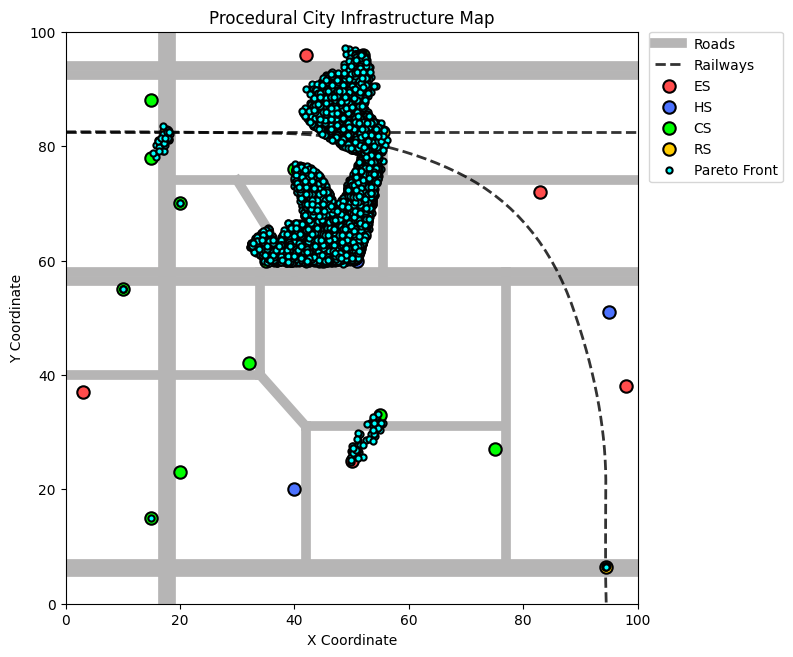

In [294]:
# Extract the optimal positions from the Global Best Archive
best_positions, best_fitnesses = best.extract_arrays()

# Plot them with a distinct style (e.g., large cyan stars)
plot_city_map_with_solutions(
    facilities, 
    infrastructure, 
    map_styles, 
    best_positions, 
    label="Pareto Front", 
    color="#00ffff", 
    marker="o",
    size=20
)

C:\Users\silvi\AppData\Local\Temp\ipykernel_11296\1829285541.py:71: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, color=color, marker=marker, s=size,


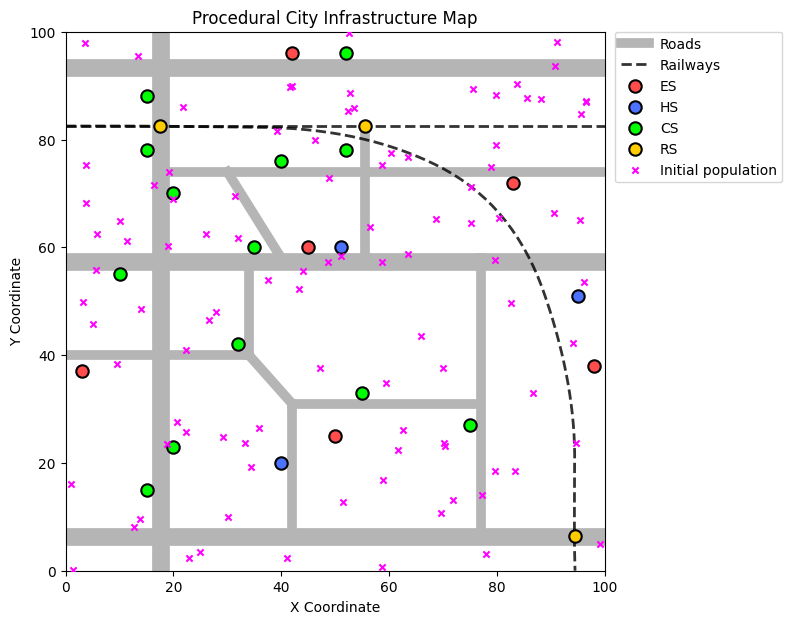

In [295]:
# intitial population positions
iteration_0_pop = hist[0]

plot_city_map_with_solutions(
    facilities, 
    infrastructure, 
    map_styles, 
    iteration_0_pop, 
    label="Initial population", 
    color="#ff00ff", 
    marker="x",
    size=20
)

C:\Users\silvi\AppData\Local\Temp\ipykernel_11296\1829285541.py:71: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, color=color, marker=marker, s=size,


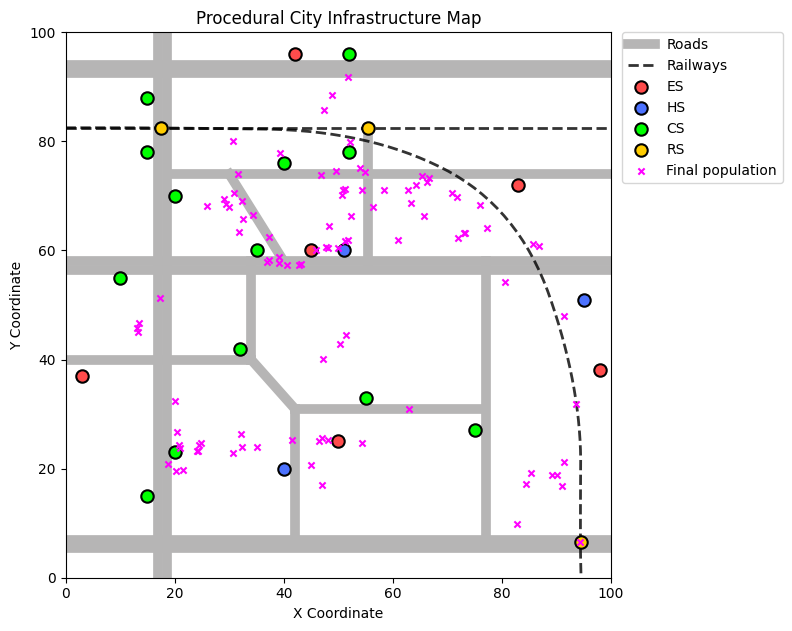

In [300]:
# Population positions at the iteration
iteration_pop = hist[-1]

plot_city_map_with_solutions(
    facilities, 
    infrastructure, 
    map_styles, 
    iteration_pop, 
    label="Final population", 
    color="#ff00ff", 
    marker="x",
    size=20
)